In [8]:

import glob
import os
import datetime
from astropy.table import Table
filtername = 'F480M'
basepath = '/orange/adamginsburg/jwst/w51/'

from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f150w": "/orange/adamginsburg/jwst/w51/F150W/pipeline/jw06151-o001_t001_nircam_clear-f150w-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}
nircam_short_filters = ['F140M', 'F162M', 'F182M', 'F187N', 'F210M' ]
nircam_long_filters = [ 'F335M',  'F360M','F405N', 'F410M',  'F480M']
miri_filters = ['F560W', 'F770W', 'F1000W',  'F1280W',  'F2100W', ]
def tblname_to_imgname(tblname,  proposal_id='6151'):
    filtername = tblname.split('/')[-1].split('_')[0]
    if filtername.upper() in miri_filters:
        target= 'w51_miri'
    else:        
        target = 'w51'

    nvisits = {'2221': {'brick': 1, 'cloudc': 2},
                '1182': {'brick': 2},
                '6151': {'w51': 1, 'w51_miri': 2}
                }
    field_to_reg_mapping = {'2221': {'001': 'brick', '002': 'cloudc'},
                            '1182': {'004': 'brick'},
                            '6151': {'001': 'w51', '002':'w51_miri'}}[proposal_id]
    reg_to_field_mapping = {v:k for k,v in field_to_reg_mapping.items()}
    field = reg_to_field_mapping[target]


    
    module = tblname.split('/')[-1].split('_')[1]
    visit = tblname.split('/')[-1].split('_')[2]
    visitid = visit[5:]
    vgroup = tblname.split('/')[-1].split('_')[3]
    vgroupid = vgroup[6:]
    exposure = tblname.split('/')[-1].split('_')[4]
    expid = exposure[3:]
    imgname = f'{basepath}/{filtername.upper()}/pipeline/jw0{proposal_id}{field}{visitid}_{vgroupid}_{expid}_{module}_cal.fits'


    return imgname
def load_data(filename):
    fh = fits.open(filename)
    im1 = fh
    data = im1['SCI'].data
    try:
        wht = im1['WHT'].data
    except KeyError:
        wht = None
    err = im1['ERR'].data
    instrument = im1[0].header['INSTRUME']
    telescope = im1[0].header['TELESCOP']
    obsdate = im1[0].header['DATE-OBS']
    return fh, im1, data, wht, err, instrument, telescope, obsdate

/orange/adamginsburg/jwst/w51//F560W/f560w_mirimage_visit002_vgroup0210b_exp00002_daophot_combined_with_satstars.fits
last modified: 2026-03-12 16:04:29
/orange/adamginsburg/jwst/w51//F560W/f560w_mirimage_visit001_vgroup02101_exp00004_daophot_combined_with_satstars.fits
last modified: 2026-03-12 16:04:27
/orange/adamginsburg/jwst/w51//F560W/f560w_mirimage_visit001_vgroup02101_exp00003_daophot_combined_with_satstars.fits
last modified: 2026-03-12 16:04:26
/orange/adamginsburg/jwst/w51//F560W/f560w_mirimage_visit001_vgroup0210b_exp00002_daophot_combined_with_satstars.fits
last modified: 2026-03-12 16:04:27
/orange/adamginsburg/jwst/w51//F560W/f560w_mirimage_visit002_vgroup02101_exp00003_daophot_combined_with_satstars.fits
last modified: 2026-03-12 16:04:30
/orange/adamginsburg/jwst/w51//F560W/f560w_mirimage_visit001_vgroup02101_exp00001_daophot_combined_with_satstars.fits
last modified: 2026-03-12 16:04:25
/orange/adamginsburg/jwst/w51//F560W/f560w_mirimage_visit002_vgroup02101_exp00001_

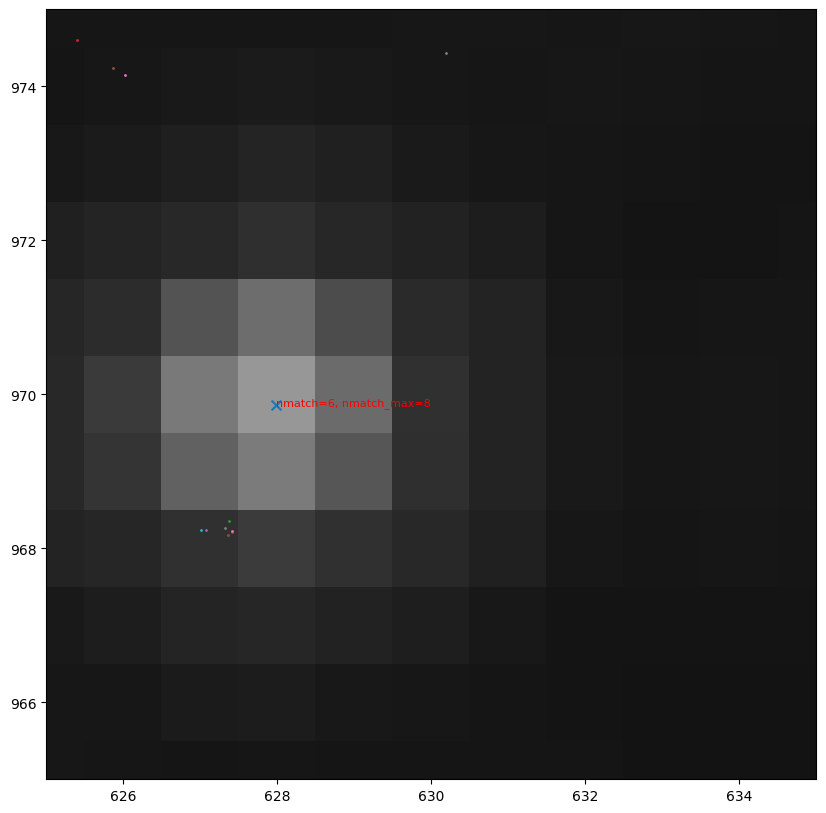

In [9]:
xlims = [625,635]
ylims = [965,975]
filternames=  ['F560W']
for filtername in filternames:
    tblfns = glob.glob(f'{basepath}/{filtername.upper()}/*daophot_combined_with_satstars.fits')
    for tbl in tblfns:
        print(tbl)
        print('last modified:', datetime.datetime.fromtimestamp(os.path.getmtime(tbl)))

    tblfns_merged = glob.glob(f'/orange/adamginsburg/jwst/w51/catalogs/{filtername.lower()}_*_indivexp_merged_dao_after_merger_combined_with_satstars_fixed.fits')
    print('last modified:', datetime.datetime.fromtimestamp(os.path.getmtime(tblfns_merged[0])))

    tbls = [Table.read(tblfn) for tblfn in tblfns]
    tbls_merged = [Table.read(tblfn) for tblfn in tblfns_merged]

    imgfn = image_filenames[filtername.lower()]
    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(111)
    fh, im1, data, wht, err, instrument, telescope, obsdate = load_data(imgfn)
    ww = WCS(im1['SCI'].header)
    for tbs_merged in tbls_merged:
        skycoord_merged = tbs_merged['skycoord']
        for ii, tbl in enumerate(tbls):
            img_name = tblname_to_imgname(tblfns[ii])
            fh, im1, img_data, wht, err, instrument, telescope, obsdate = load_data(img_name)
            wcs = WCS(im1[1].header)
            pixcoord_merged = wcs.world_to_pixel(skycoord_merged)
            
            
            # check whether pixel coordiantes of tbl_merged fall within the image field of view
            
            
            img_shape = img_data.shape
            in_fov = (pixcoord_merged[0] >= 0) & (pixcoord_merged[0] < img_shape[1]) & (pixcoord_merged[1] >= 0) & (pixcoord_merged[1] < img_shape[0])
            in_fov_int = in_fov.astype(int)
            
            # stack in_fov while looping over tbls to get a final mask of which sources in tbl_merged are in the field of view of at least one tbl in tbls
            if ii == 0:
                in_fov_all = in_fov_int
            else:
                in_fov_all = in_fov_all + in_fov_int
    nmatch_max = in_fov_all


    ax.imshow(load_data(imgfn)[2], origin='lower', cmap='gray', norm=simple_norm(load_data(imgfn)[2], 'sqrt', percent=99.5))
    for tbl in tbls_merged:
        print(tbl.colnames)
        skycoord = tbl['skycoord']
        pixcoord = ww.world_to_pixel(skycoord)
        ax.scatter(pixcoord[0], pixcoord[1], s=50, marker='x', label='merged')
        nmatch = tbl['nmatch']
        idx_in = np.where((pixcoord[0] >= xlims[0]) & (pixcoord[0] <= xlims[1]) & (pixcoord[1] >= ylims[0]) & (pixcoord[1] <= ylims[1]))
        for idx in idx_in[0]:
            ax.annotate(f'nmatch={nmatch[idx]}, nmatch_max={nmatch_max[idx]}', (pixcoord[0][idx], pixcoord[1][idx]), color='red', fontsize=8)
    for tbl in tbls:
        skycoord = tbl['skycoord_centroid']
        pixcoord = ww.world_to_pixel(skycoord)
        ax.scatter(pixcoord[0], pixcoord[1], s=1, label='individual exp')
    ax.set_xlim(xlims)
    ax.set_ylim(ylims)



/orange/adamginsburg/jwst/w51//F560W/f560w_mirimage_visit002_vgroup0210b_exp00002_daophot_combined_with_satstars.fits
last modified: 2026-03-12 16:04:29
/orange/adamginsburg/jwst/w51//F560W/f560w_mirimage_visit001_vgroup02101_exp00004_daophot_combined_with_satstars.fits
last modified: 2026-03-12 16:04:27
/orange/adamginsburg/jwst/w51//F560W/f560w_mirimage_visit001_vgroup02101_exp00003_daophot_combined_with_satstars.fits
last modified: 2026-03-12 16:04:26
/orange/adamginsburg/jwst/w51//F560W/f560w_mirimage_visit001_vgroup0210b_exp00002_daophot_combined_with_satstars.fits
last modified: 2026-03-12 16:04:27
/orange/adamginsburg/jwst/w51//F560W/f560w_mirimage_visit002_vgroup02101_exp00003_daophot_combined_with_satstars.fits
last modified: 2026-03-12 16:04:30
/orange/adamginsburg/jwst/w51//F560W/f560w_mirimage_visit001_vgroup02101_exp00001_daophot_combined_with_satstars.fits
last modified: 2026-03-12 16:04:25
/orange/adamginsburg/jwst/w51//F560W/f560w_mirimage_visit002_vgroup02101_exp00001_

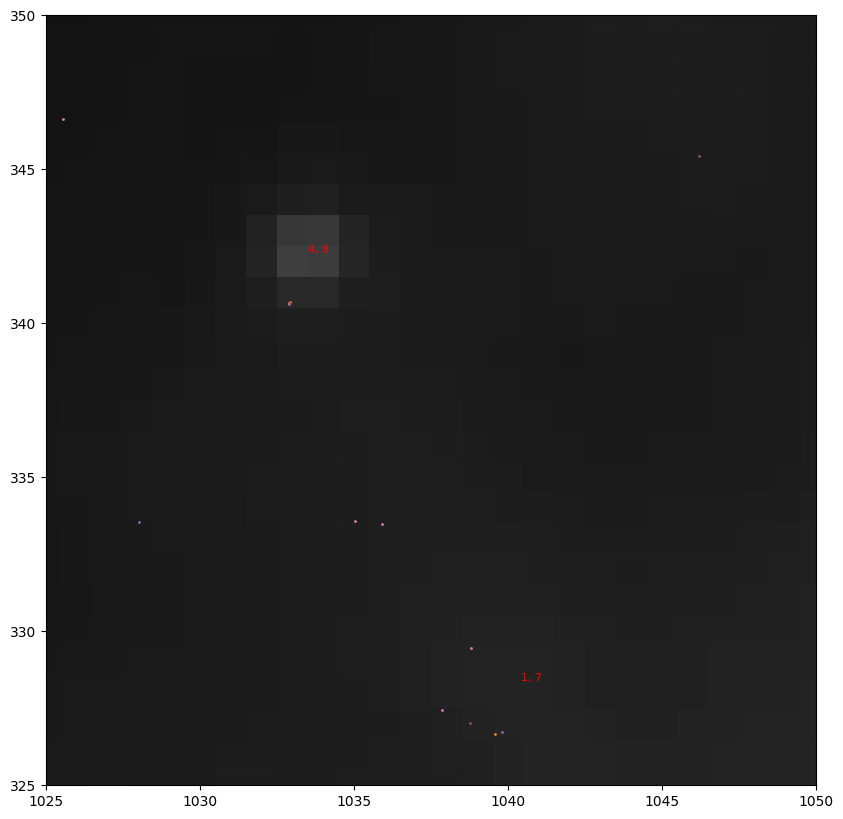

In [11]:
xlims = [1025,1050]
ylims = [325,350]
filternames=  ['F560W']
for filtername in filternames:
    tblfns = glob.glob(f'{basepath}/{filtername.upper()}/*daophot_combined_with_satstars.fits')
    for tbl in tblfns:
        print(tbl)
        print('last modified:', datetime.datetime.fromtimestamp(os.path.getmtime(tbl)))

    tblfns_merged = glob.glob(f'/orange/adamginsburg/jwst/w51/catalogs/{filtername.lower()}_*_indivexp_merged_dao_after_merger_combined_with_satstars_fixed.fits')
    print('last modified:', datetime.datetime.fromtimestamp(os.path.getmtime(tblfns_merged[0])))

    tbls = [Table.read(tblfn) for tblfn in tblfns]
    tbls_merged = [Table.read(tblfn) for tblfn in tblfns_merged]

    imgfn = image_filenames[filtername.lower()]
    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(111)
    fh, im1, data, wht, err, instrument, telescope, obsdate = load_data(imgfn)
    ww = WCS(im1['SCI'].header)
    for tbs_merged in tbls_merged:
        skycoord_merged = tbs_merged['skycoord']
        for ii, tbl in enumerate(tbls):
            img_name = tblname_to_imgname(tblfns[ii])
            fh, im1, img_data, wht, err, instrument, telescope, obsdate = load_data(img_name)
            wcs = WCS(im1[1].header)
            pixcoord_merged = wcs.world_to_pixel(skycoord_merged)
            
            
            # check whether pixel coordiantes of tbl_merged fall within the image field of view
            
            
            img_shape = img_data.shape
            in_fov = (pixcoord_merged[0] >= 0) & (pixcoord_merged[0] < img_shape[1]) & (pixcoord_merged[1] >= 0) & (pixcoord_merged[1] < img_shape[0])
            in_fov_int = in_fov.astype(int)
            
            # stack in_fov while looping over tbls to get a final mask of which sources in tbl_merged are in the field of view of at least one tbl in tbls
            if ii == 0:
                in_fov_all = in_fov_int
            else:
                in_fov_all = in_fov_all + in_fov_int
    nmatch_max = in_fov_all


    ax.imshow(load_data(imgfn)[2], origin='lower', cmap='gray', norm=simple_norm(load_data(imgfn)[2], 'sqrt', percent=99.5))
    for tbl in tbls_merged:
        print(tbl.colnames)
        skycoord = tbl['skycoord']
        pixcoord = ww.world_to_pixel(skycoord)
        #ax.scatter(pixcoord[0], pixcoord[1], s=50, marker='x', label='merged')
        nmatch = tbl['nmatch']
        idx_in = np.where((pixcoord[0] >= xlims[0]) & (pixcoord[0] <= xlims[1]) & (pixcoord[1] >= ylims[0]) & (pixcoord[1] <= ylims[1]))
        for idx in idx_in[0]:
            ax.annotate(f'{nmatch[idx]}, {nmatch_max[idx]}', (pixcoord[0][idx], pixcoord[1][idx]), color='red', fontsize=8)
    for tbl in tbls:
        skycoord = tbl['skycoord_centroid']
        pixcoord = ww.world_to_pixel(skycoord)
        ax.scatter(pixcoord[0], pixcoord[1], s=1, label='individual exp')
    ax.set_xlim(xlims)
    ax.set_ylim(ylims)

